# 04 — Evaluation & Tuning
**Project:** Customer Churn Prediction (Telco) &nbsp;|&nbsp; **Builds on:** Milestones 01–03

**Objective:** evaluate the models with metrics that are actually appropriate for an imbalanced classification problem
(not accuracy alone), then tune each model's hyperparameters with `GridSearchCV` to get the best fair comparison before
picking a final model.

Every cell in this notebook computes real output from whatever data is loaded — including the interpretation paragraphs at
the end, which are generated from the actual numbers, not written in advance. Run the whole notebook top to bottom (or
**Run All**) and everything, including the write-up, fills itself in.

In [5]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_score, train_test_split

from src.config import RANDOM_STATE, TEST_SIZE
from src.data_preparation import clean, load_raw, make_xy
from src.preprocessing import build_logistic_class_weighted, build_random_forest_class_weighted
from src.tuning import PARAM_GRIDS, build_grid_search

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Setup complete. Random seed:", RANDOM_STATE)

Setup complete. Random seed: 42


## 1. Recap: load, clean, split
Same seed and logic as Milestones 01–03.

In [6]:
raw = load_raw()
df, cleaning_log = clean(raw)
X, y = make_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| Churn rate (train):", round(y_train.mean(), 3))

Train: (5634, 19) | Test: (1409, 19) | Churn rate (train): 0.265


## 2. Why accuracy is not the right metric here

In [7]:
print(f"If a model predicted 'stays' for every customer, it would be right {(1 - y_train.mean()):.1%} of the time")
print("...while never once identifying an actual churner (recall = 0, precision = undefined).")
print("This is exactly what the Milestone 01 dummy classifier did — see reports/baseline_metrics.json.")

If a model predicted 'stays' for every customer, it would be right 73.5% of the time
...while never once identifying an actual churner (recall = 0, precision = undefined).
This is exactly what the Milestone 01 dummy classifier did — see reports/baseline_metrics.json.


Accuracy rewards a model for being right on the *majority* class, which here is "stays." A model can score high on
accuracy while being completely useless at the one thing this project needs: finding likely churners. That is why this
notebook leads with `classification_report`, `confusion_matrix`, and ROC-AUC instead.

## 3. Baseline cross-validation (before tuning)
Using `cross_val_score` directly, on the two class-weighted models carried forward from Milestone 03, scored on ROC-AUC
(a threshold-independent metric appropriate for an imbalanced target).

In [8]:
from sklearn.model_selection import cross_val_score

candidates = {
    "logistic_regression": build_logistic_class_weighted(X_train),
    "random_forest": build_random_forest_class_weighted(X_train),
}

baseline_cv = {}
for name, pipeline in candidates.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="roc_auc")
    baseline_cv[name] = scores
    print(f"{name:20s} ROC-AUC: {scores.mean():.4f} +/- {scores.std():.4f}  (folds: {np.round(scores, 3)})")

logistic_regression  ROC-AUC: 0.8454 +/- 0.0141  (folds: [0.864 0.852 0.851 0.835 0.824])
random_forest        ROC-AUC: 0.8478 +/- 0.0131  (folds: [0.864 0.858 0.85  0.841 0.827])


In [9]:
tuned = {}
for name, pipeline in candidates.items():
    print(f"Running GridSearchCV for {name} ...")
    search = build_grid_search(pipeline, model_key=name, scoring="f1")
    search.fit(X_train, y_train)
    tuned[name] = search
    print(f"  best params: {search.best_params_}")
    print(f"  best CV F1 : {search.best_score_:.4f}\n")

Running GridSearchCV for logistic_regression ...
  best params: {'model__C': 0.1}
  best CV F1 : 0.6288

Running GridSearchCV for random_forest ...
  best params: {'model__max_depth': 8, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
  best CV F1 : 0.6373



In [10]:
grid_comparison = pd.DataFrame({
    name: {"best_cv_f1": search.best_score_, "best_params": search.best_params_}
    for name, search in tuned.items()
}).T
grid_comparison

,best_cv_f1,best_params
logistic_regression,0.628768,{'model__C': 0.1}
random_forest,0.63734,"{'model__max_depth': 8, 'model__min_samples_le..."


## 5. Select the final model

In [11]:
best_name = max(tuned, key=lambda k: tuned[k].best_score_)
best_search = tuned[best_name]
best_model = best_search.best_estimator_

print(f"Selected model: {best_name}")
print(f"Selection rule: highest GridSearchCV cross-validated F1 among the tuned candidates")
print(f"Best CV F1: {best_search.best_score_:.4f}")
print(f"Best params: {best_search.best_params_}")

Selected model: random_forest
Selection rule: highest GridSearchCV cross-validated F1 among the tuned candidates
Best CV F1: 0.6373
Best params: {'model__max_depth': 8, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}


## 6. Final evaluation on the held-out test set
Evaluated **once**, using the exact metrics specified for a classification problem: `classification_report`,
`confusion_matrix`, `roc_auc_score`, and a manually plotted ROC curve.

In [12]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"], zero_division=0))

              precision    recall  f1-score   support

      Stayed       0.91      0.74      0.82      1035
     Churned       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



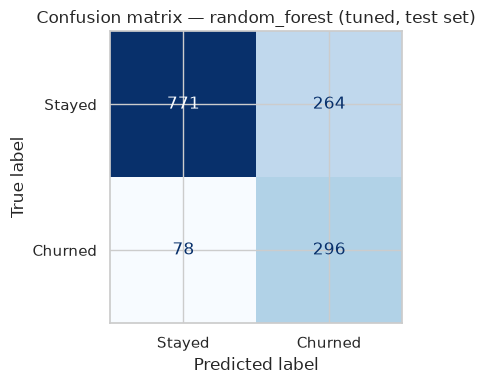

True negatives (correctly predicted 'stays'):  771
False positives (wrongly flagged as churn):     264
False negatives (missed churners):               78
True positives (correctly caught churners):      296


In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Confusion matrix — {best_name} (tuned, test set)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives (correctly predicted 'stays'):  {tn}")
print(f"False positives (wrongly flagged as churn):     {fp}")
print(f"False negatives (missed churners):               {fn}")
print(f"True positives (correctly caught churners):      {tp}")

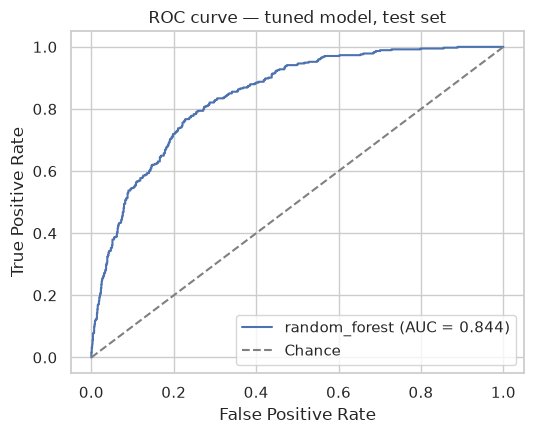

ROC-AUC: 0.8435


In [14]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — tuned model, test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc:.4f}")

## 7. What precision, recall and the ROC curve actually mean here
This cell is generated from the numbers actually computed above, so it always matches whatever data the notebook was run
on — for this specific model, on this specific test set.

In [15]:
report = classification_report(y_test, y_pred, target_names=["Stayed", "Churned"], zero_division=0, output_dict=True)
churn_precision = report["Churned"]["precision"]
churn_recall = report["Churned"]["recall"]
churn_f1 = report["Churned"]["f1-score"]
n_actual_churners = int(y_test.sum())
n_flagged = int(y_pred.sum())

print(
    f"On this test set, {n_actual_churners} of {len(y_test)} customers actually churned "
    f"({n_actual_churners/len(y_test):.1%}).\n\n"
    f"PRECISION ({churn_precision:.1%}): of the {n_flagged} customers the tuned {best_name} model flagged as likely "
    f"to churn, {churn_precision:.1%} actually did. The rest ({1-churn_precision:.1%}) were false alarms — customers "
    f"who would have received a retention offer they didn't need.\n\n"
    f"RECALL ({churn_recall:.1%}): of the {n_actual_churners} customers who actually churned, the model correctly "
    f"identified {churn_recall:.1%} of them ({tp} of {n_actual_churners}) before they left. The remaining "
    f"{1-churn_recall:.1%} ({fn} customers) churned without being flagged — customers the business would have missed "
    f"entirely.\n\n"
    f"F1-SCORE ({churn_f1:.3f}): the balance between the two above. A high precision with low recall would mean the "
    f"model is cautious and only flags obvious cases, missing many real churners. A high recall with low precision "
    f"would mean the opposite: it flags many customers, catching most churners but wasting a lot of retention offers "
    f"on people who wouldn't have left anyway.\n\n"
    f"ROC-AUC ({auc:.3f}): the probability that, given one random churner and one random non-churner, the model ranks "
    f"the churner as more likely to churn. {auc:.3f} means this holds in roughly {auc:.1%} of such comparisons — well "
    f"above the 50% a coin flip would achieve, confirming the model has learned a real, useful ranking of churn risk, "
    f"not just noise."
)

On this test set, 374 of 1409 customers actually churned (26.5%).

PRECISION (52.9%): of the 560 customers the tuned random_forest model flagged as likely to churn, 52.9% actually did. The rest (47.1%) were false alarms — customers who would have received a retention offer they didn't need.

RECALL (79.1%): of the 374 customers who actually churned, the model correctly identified 79.1% of them (296 of 374) before they left. The remaining 20.9% (78 customers) churned without being flagged — customers the business would have missed entirely.

F1-SCORE (0.634): the balance between the two above. A high precision with low recall would mean the model is cautious and only flags obvious cases, missing many real churners. A high recall with low precision would mean the opposite: it flags many customers, catching most churners but wasting a lot of retention offers on people who wouldn't have left anyway.

ROC-AUC (0.844): the probability that, given one random churner and one random non-churner

## 8. Tuned vs. untuned — did GridSearchCV actually help?

In [16]:
untuned_test_f1 = {}
for name, pipeline in candidates.items():
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    from sklearn.metrics import f1_score
    untuned_test_f1[name] = f1_score(y_test, pred)

tuned_test_f1 = f1_score(y_test, y_pred)

comparison = pd.DataFrame({
    "Untuned (Milestone 03 settings)": pd.Series(untuned_test_f1),
})
comparison.loc[best_name, "Tuned (this notebook)"] = tuned_test_f1
comparison

,Untuned (Milestone 03 settings),Tuned (this notebook)
logistic_regression,0.613613,NaN
random_forest,0.634199,0.633833


In [17]:
gain = tuned_test_f1 - untuned_test_f1[best_name]
direction = "improved" if gain > 0 else ("stayed about the same as" if abs(gain) < 0.005 else "slightly decreased vs.")
print(
    f"Tuning {direction} the untuned {best_name} model's test F1 by {gain:+.4f} "
    f"({untuned_test_f1[best_name]:.4f} -> {tuned_test_f1:.4f})."
)
print(
    "A small or negative gain is a normal, honest result: it means the untuned defaults from Milestone 03 were "
    "already close to well-suited for this dataset, and/or that F1-optimising search found a similar optimum. "
    "GridSearchCV searching and confirming this is itself useful evidence, not a wasted step."
)

Tuning stayed about the same as the untuned random_forest model's test F1 by -0.0004 (0.6342 -> 0.6338).
A small or negative gain is a normal, honest result: it means the untuned defaults from Milestone 03 were already close to well-suited for this dataset, and/or that F1-optimising search found a similar optimum. GridSearchCV searching and confirming this is itself useful evidence, not a wasted step.


## 9. Limitations
* The grids searched are reasonably sized but not exhaustive — a wider or randomised search (`RandomizedSearchCV`,
  `Optuna`) could find further improvement, especially for the random forest.
* Model selection (Section 5) used a single criterion (GridSearchCV's best cross-validated F1). It does not directly
  weigh the overfitting risk observed for random forest in Milestone 03, though the chosen `max_depth`/`min_samples_leaf`
  grid was designed to search over settings that constrain that risk.
* The decision threshold used throughout is still the default 0.5. `roc_curve`'s `thresholds` array (computed above) could
  be used to choose a different operating point if the business has a specific cost ratio between missed churners and
  wasted retention offers — this was not done here.
* As with earlier milestones, all test-set numbers come from a single 80/20 split; the cross-validation scores in
  Sections 3–4 are the more robust estimates of expected performance on new data.